<img src="./image/实验07.png" alt="实验07" style="zoom:50%;">

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import chardet
import seaborn as sns
import numpy as np

In [4]:
# 加载中文字体，避免中文乱码
plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题

In [5]:
# 读取数据
file1 = './data/winequality-red.csv'
with open(file1, 'rb') as f:
    result = chardet.detect(f.read())
    print(result)

wine = pd.read_csv(file1, sep=';', encoding=result['encoding'])

{'encoding': 'ascii', 'confidence': 1.0, 'language': ''}


1.(1)
quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64


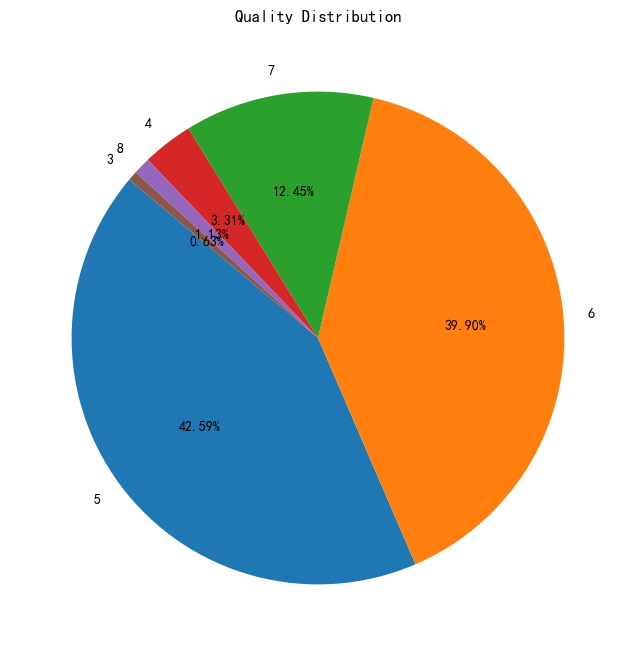

In [18]:
print('1.(1)')
quality_distribution = wine['quality'].value_counts()
print(quality_distribution)

plt.figure(figsize=(8, 8))
plt.pie(quality_distribution, labels=quality_distribution.index,
        autopct='%.2f%%', startangle=140)
plt.title('Quality Distribution')
plt.show()

1.(2)


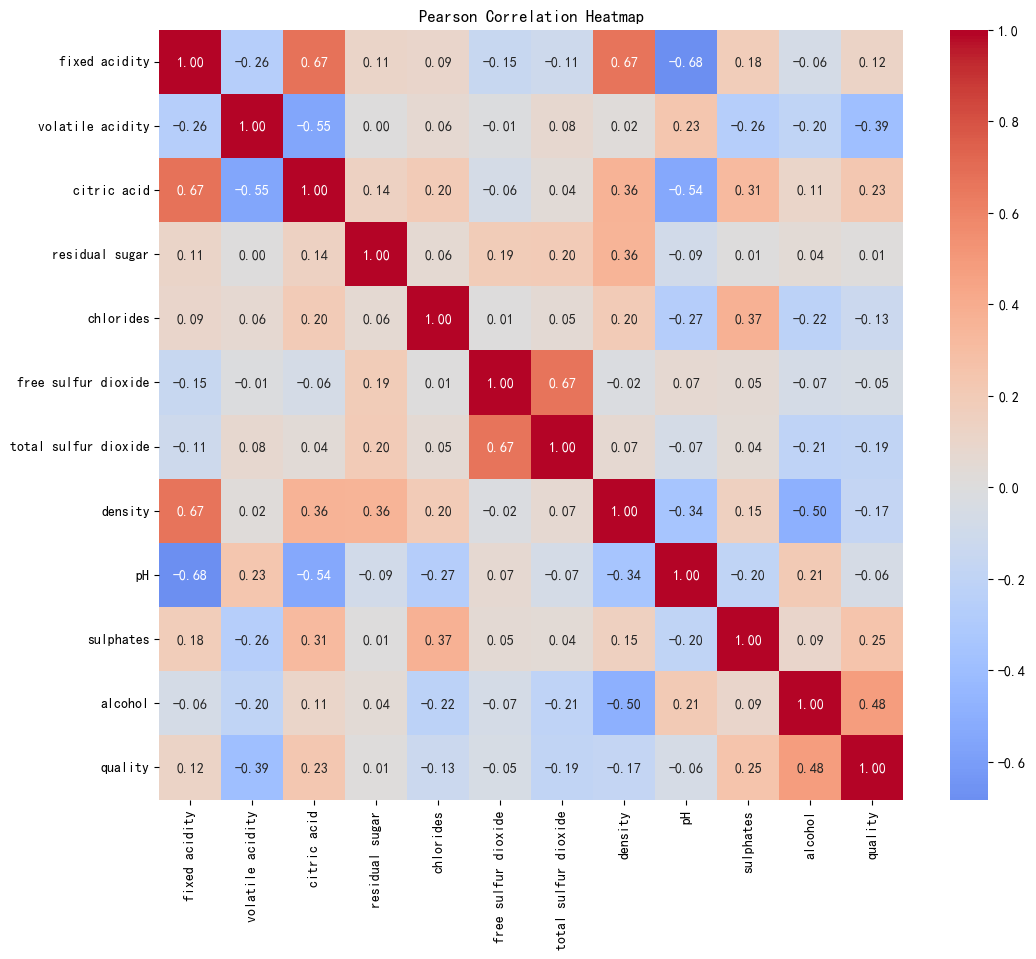

In [7]:
print('1.(2)')
correlation_matrix = wine.corr(numeric_only=True)
# 提取 quality 列与其他属性的相关系数
quality_correlation = correlation_matrix['quality']

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Pearson Correlation Heatmap')
plt.show()

In [8]:
lending_df = pd.read_csv('./data/Lending.dat', encoding='utf-8')
lending_df['date'] = pd.to_datetime(lending_df['date'])

In [9]:
print('2.(1)')
user_book_count = lending_df.groupby('uid')['bid'].count().reset_index(
                    name='借书数量')
print("每个用户借的书的数量：")
print(user_book_count)

2.(1)
每个用户借的书的数量：
          uid  借书数量
0          10   551
1          13   302
2          14   128
3          19   436
4          24   189
...       ...   ...
2448  1102028   140
2449  1103310   120
2450  1104030   129
2451  1104525   105
2452  1107147   108

[2453 rows x 2 columns]


In [10]:
print('2.(2)')
top_10_users = user_book_count.nlargest(10, '借书数量')
print("借书最多的10位用户：")
print(top_10_users)


2.(2)
借书最多的10位用户：
      uid  借书数量
592  5076  1848
127   965  1388
329  2539  1199
603  5116  1113
427  3642   856
131   982   826
238  1778   805
23    177   803
160  1180   772
16     97   760


In [11]:
print('2.(3)')
user_earliest_year = lending_df.groupby('uid')['date'].min().dt.year.reset_index(
    name='最早借书年份')
print("每个用户最早借书的年份：")
print(user_earliest_year)

2.(3)
每个用户最早借书的年份：
          uid  最早借书年份
0          10    2011
1          13    2015
2          14    2015
3          19    2015
4          24    2013
...       ...     ...
2448  1102028    2015
2449  1103310    2016
2450  1104030    2015
2451  1104525    2015
2452  1107147    2015

[2453 rows x 2 columns]


In [12]:
print('2.(4)')
user_yearly_count = lending_df.groupby(
    ['uid',lending_df['date'].dt.year])['bid'].count().reset_index(
        name='当年借书数量')
print("\n每个用户每年借书的数量：")
print(user_yearly_count)

2.(4)

每个用户每年借书的数量：
           uid  date  当年借书数量
0           10  2011     100
1           10  2012      95
2           10  2013      92
3           10  2014      43
4           10  2015      69
...        ...   ...     ...
10517  1104525  2017      15
10518  1104525  2018       5
10519  1107147  2015      66
10520  1107147  2016      28
10521  1107147  2017      14

[10522 rows x 3 columns]


In [13]:
print('2.(5)')
avg_yearly_count = user_yearly_count.groupby(
    'uid')['当年借书数量'].mean().reset_index(name='平均年借书量')
top_10_avg_users = avg_yearly_count.nlargest(10, '平均年借书量')
print("\n平均年借书量最多的十位用户信息：")
print(top_10_avg_users)

2.(5)

平均年借书量最多的十位用户信息：
       uid  平均年借书量
1133  8445  555.00
592   5076  369.60
798   6085  279.00
603   5116  278.25
127    965  277.60
826   6272  252.00
959   7244  242.00
549   4869  223.00
937   7072  214.50
753   5850  182.00


In [14]:
population_df = pd.read_excel('./data/分省年度-年末常住人口(万人).xlsx',header=3, nrows=31)
region_col = ['地区']  # 保留首列"地区"
year_cols = [col for col in population_df.columns if col != '地区']  # 获取所有年份列（排除"地区"）
sorted_year_cols = sorted(year_cols, key=lambda x: int(x.strip('年')))  # 按升序排序年份
population_df = population_df[region_col + sorted_year_cols]  # 重新排列列顺序
population_df.head()

,地区,2000年,2001年,2002年,2003年,2004年,2005年,2006年,2007年,2008年,...,2013年,2014年,2015年,2016年,2017年,2018年,2019年,2020年,2021年,2022年
0,北京市,1364,1385,1423,1456,1493,1538,1601,1676,1771,...,2125,2171,2188,2195,2194,2192,2190,2189,2189,2184
1,天津市,1001,1004,1007,1011,1024,1043,1075,1115,1176,...,1410,1429,1439,1443,1410,1383,1385,1387,1373,1363
2,河北省,6674,6699,6735,6769,6809,6851,6898,6943,6989,...,7288,7323,7345,7375,7409,7426,7447,7464,7448,7420
3,山西省,3247,3272,3294,3314,3335,3355,3375,3393,3411,...,3535,3528,3519,3514,3510,3502,3497,3490,3480,3481
4,内蒙古自治区,2372,2381,2384,2386,2393,2403,2415,2429,2444,...,2455,2449,2440,2436,2433,2422,2415,2403,2400,2401


3.(1)


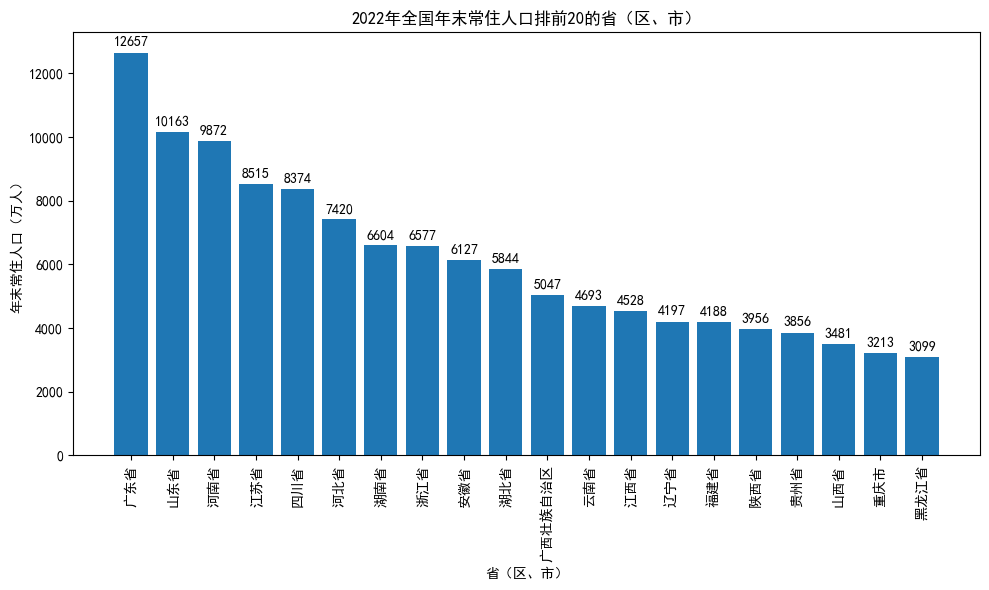

In [15]:
print('3.(1)')
top_20_2022 = population_df[['地区', '2022年']].nlargest(20, '2022年')

plt.figure(figsize=(10, 6))
bars = plt.bar(top_20_2022['地区'], top_20_2022['2022年'])
plt.bar_label(bars, padding=3)
plt.title('2022年全国年末常住人口排前20的省（区、市）')
plt.xlabel('省（区、市）')
plt.ylabel('年末常住人口（万人）')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

3.(2)


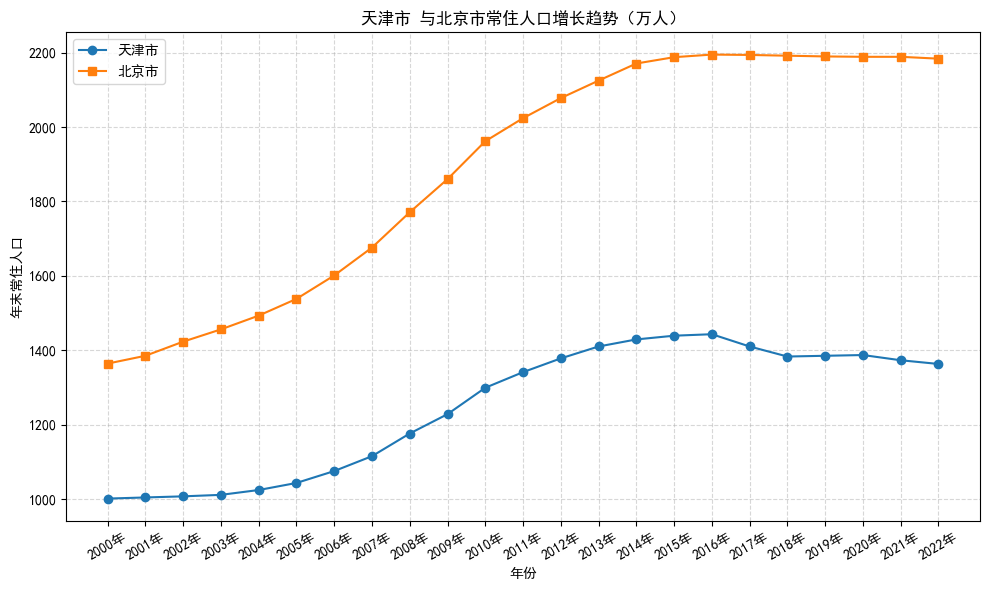

In [16]:
print('3.(2)')
your_hometown = '天津市'
hometown_trend = population_df[population_df['地区'] == your_hometown].drop(columns='地区').T
beijing_trend = population_df[population_df['地区'] == '北京市'].drop(columns='地区').T

plt.figure(figsize=(10, 6))
plt.plot(hometown_trend.index, hometown_trend.iloc[:,0], label=your_hometown, marker='o')
plt.plot(beijing_trend.index, beijing_trend.iloc[:,0], label='北京市', marker='s')
plt.title(f'{your_hometown} 与北京市常住人口增长趋势（万人）')
plt.xlabel('年份')
plt.ylabel('年末常住人口')
plt.xticks(rotation=30)
plt.grid(linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

3.(3)


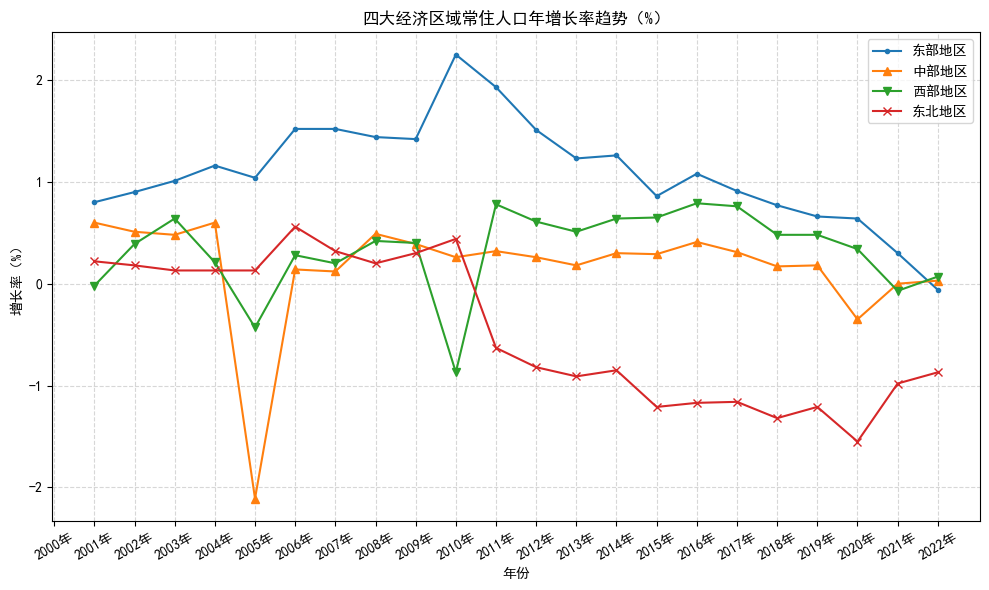

In [17]:
print('3.(3)')
# 定义四大经济区域包含的省份
east = ['北京市', '天津市', '河北省', '上海市', '江苏省', '浙江省', '福建省', '山东省', '广东省', '海南省']
central = ['山西省', '安徽省', '江西省', '河南省', '湖北省', '湖南省']
west = ['内蒙古自治区', '广西壮族自治区', '重庆市', '四川省', '贵州省', '云南省', '西藏自治区', '陕西省', '甘肃省', '青海省', '宁夏回族自治区', '新疆维吾尔自治区']
northeast = ['辽宁省', '吉林省', '黑龙江省']

def get_region_pop(region_list):
    return population_df[population_df['地区'].isin(region_list)].drop(columns='地区').sum()

def calc_growth_rate(series):
    return (series.pct_change() * 100).round(2)  # 保留2位小数

# 计算各区域总人口
east_pop = get_region_pop(east)
central_pop = get_region_pop(central)
west_pop = get_region_pop(west)
northeast_pop = get_region_pop(northeast)

# 计算增长率（(当年人口 - 上年人口)/上年人口 * 100）
east_growth = calc_growth_rate(east_pop)
central_growth = calc_growth_rate(central_pop)
west_growth = calc_growth_rate(west_pop)
northeast_growth = calc_growth_rate(northeast_pop)

# 绘制增长率趋势图
plt.figure(figsize=(10, 6))
plt.plot(east_growth.index, east_growth, label='东部地区', marker='.')
plt.plot(central_growth.index, central_growth, label='中部地区', marker='^')
plt.plot(west_growth.index, west_growth, label='西部地区', marker='v')
plt.plot(northeast_growth.index, northeast_growth, label='东北地区', marker='x')
plt.title('四大经济区域常住人口年增长率趋势（%）')
plt.xlabel('年份')
plt.ylabel('增长率（%）')
plt.xticks(rotation=30)
plt.grid(linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()